# AI-Powered Adverse Event Summarizer from Patient Reviews

## Data Source and Collection

### 1. Authenticate with Kaggle
This cell retrieves your Kaggle credentials securely from Colab's Secrets manager.

In [ ]:
import os
from google.colab import userdata

# Securely load Kaggle credentials
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("Kaggle credentials loaded successfully!")
except userdata.SecretNotFoundError:
    print("Error: Please ensure you have added KAGGLE_USERNAME and KAGGLE_KEY to Colab Secrets.")

Kaggle credentials loaded successfully!


### 2. Download and Unzip the Dataset
We will download the `jessicali9530/kuc-hackathon-winter-2018` dataset, which contains patient reviews, conditions, and ratings.

In [ ]:
# Download the dataset using Kaggle CLI
!kaggle datasets download -d jessicali9530/kuc-hackathon-winter-2018

# Create a directory and extract the files
!mkdir -p drug_reviews_dataset
!unzip -o -q kuc-hackathon-winter-2018.zip -d drug_reviews_dataset

print("Dataset downloaded and extracted to the 'drug_reviews_dataset' folder.")

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018
License(s): other
100% 40.7M/40.7M [00:00<00:00, 135MB/s]

Dataset downloaded and extracted to the 'drug_reviews_dataset' folder.


### 3. Verify the Dataset
Let's load the training set to verify the columns and structure.

In [ ]:
import pandas as pd

# Load the raw training data
df_train = pd.read_csv('drug_reviews_dataset/drugsComTrain_raw.csv')

# Display the dataset structure and first few rows
print(f"Dataset Shape: {df_train.shape}")
display(df_train.head())

Dataset Shape: (161297, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


*Note: Shared Google Drive section removed for privacy.*

## Dataset Characteristics
Let's document the basic properties of the dataset to help the team understand its structure, completeness, and key features.

In [ ]:
# 1. Dataset Information and Data Types
print("Dataset Information:")
df_train.info()

print("\n" + "-"*40 + "\n")

# 2. Missing Values
print("Missing Values per Column:")
display(df_train.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB

----------------------------------------

Missing Values per Column:


,0
uniqueID,0
drugName,0
condition,899
review,0
rating,0
date,0
usefulCount,0


In [ ]:
# 3. Summary Statistics for Numerical Data
print("Summary Statistics (Numerical Columns):")
display(df_train.describe())

print("\n" + "-"*40 + "\n")

# 4. Top 10 Most Common Conditions
print("Top 10 Most Common Conditions:")
display(df_train['condition'].value_counts().head(10))

Summary Statistics (Numerical Columns):


,uniqueID,rating,usefulCount
count,161297.000000,161297.000000,161297.000000
mean,115923.585305,6.994377,28.004755
std,67004.445170,3.272329,36.403742
min,2.000000,1.000000,0.000000
25%,58063.000000,5.000000,6.000000
50%,115744.000000,8.000000,16.000000
75%,173776.000000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000



----------------------------------------

Top 10 Most Common Conditions:


,count
condition,
Birth Control,28788
Depression,9069
Pain,6145
Anxiety,5904
Acne,5588
Bipolar Disorde,4224
Insomnia,3673
Weight Loss,3609
Obesity,3568


### Top 10 Most Common Drugs
Visualizing the most frequently reviewed drugs in the dataset.

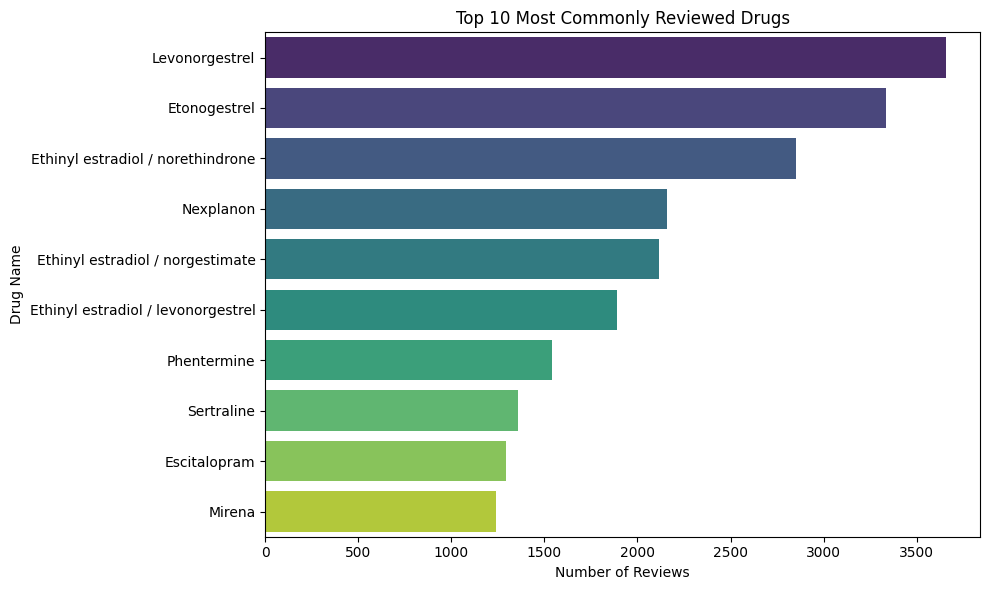

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most common drugs
top_10_drugs = df_train['drugName'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_drugs.values, y=top_10_drugs.index, hue=top_10_drugs.index, palette='viridis', legend=False)
plt.title('Top 10 Most Commonly Reviewed Drugs')
plt.xlabel('Number of Reviews')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()